In [29]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import cos, sin, log
from scipy.signal import find_peaks

Гармоника: 39.00 Гц, Амплитуда: 90.73 дБ
Гармоника: 83.00 Гц, Амплитуда: 105.06 дБ
Гармоника: 348.00 Гц, Амплитуда: 98.88 дБ
Уровень шумов (выше 10 Гц): 62.41 дБ


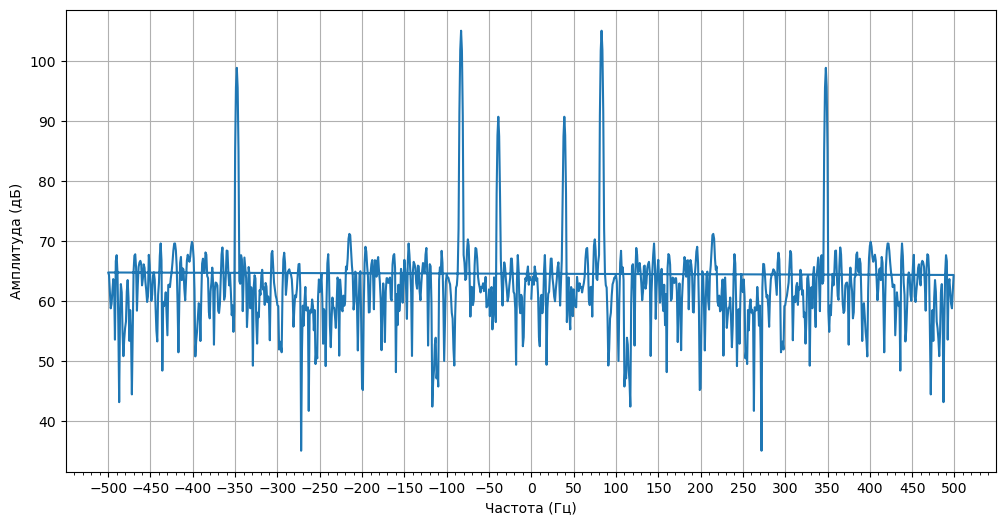

In [45]:
j=0
i=0
temp=[]
data = np.fromfile("C:\\Users\\USER F\\Desktop\\419\\2 курс\\Вычислительные методы\\4\\var09_z2.bin", dtype=np.double)
N = len(data)
for i in range(len(data-1)):
    data[i]=data[i]*len(data)*(0.355768 - 0.487396 * cos(2*np.pi*i/(N-1)) + 0.144232 * cos(4*np.pi*i/(N-1)) - 0.012604 * cos(6*np.pi*i/(N-1)))
bpf=np.fft.fft(data)
bpfa=np.abs(bpf)
bpfch=20*np.log10(bpfa)
chas=np.fft.fftfreq(len(data),1/1000)

plt.figure(figsize=(12, 6))
plt.plot(chas,bpfch)
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.grid()
ax=plt.gca()
ax.xaxis.set_major_locator(plt.MultipleLocator(50))
ax.xaxis.set_minor_locator(plt.MultipleLocator(10))

min_peak_height = 80

peaks, _ = find_peaks(bpfch, height=min_peak_height)
positive_freqs = chas[peaks][chas[peaks] > 0]
positive_amplitudes = bpfch[peaks][chas[peaks] > 0]

for freq, amp in zip(positive_freqs, positive_amplitudes):
    print(f'Гармоника: {freq:.2f} Гц, Амплитуда: {amp:.2f} дБ')

noise_threshold = 10
noise_indices = chas > noise_threshold
average_noise_level = np.mean(bpfch[noise_indices])

print(f'Уровень шумов (выше {noise_threshold} Гц): {average_noise_level:.2f} дБ')